# Convolutional Neural Network (CNN) on Fashion MNIST

**When to use a CNN:** Large datasets with complex, highly non-linear patterns — especially unstructured data (images, audio, text) — where hand-crafted features are hard to design.

## Overview

Fashion MNIST contains 70,000 grayscale 28×28 images of clothing across 10 classes. It is a drop-in replacement for classic MNIST, but is a harder, more realistic classification task — ideal for demonstrating a CNN following the guidelines:

1. Task & dataset
2. Data cleaning & preparation
3. Exploratory Data Analysis (EDA)
4. Train/validation/test split
5. Model training (forward pass, backprop, optimiser)
6. Evaluation metrics & loss curves
7. Error analysis
8. Pros, cons & real-world examples

## Setup & Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
)

np.random.seed(42)
tf.random.set_seed(42)
sns.set_theme(style="whitegrid")

print('TensorFlow version:', tf.__version__)

TensorFlow version: 2.22.0-rc0


## 1. The Dataset

Fashion MNIST is loaded via `keras.datasets`. It is already split into 60,000 training and 10,000 test images.

**Nature of dataset needed:** Large volume of data ideally; numeric tensors (images as pixel arrays).

In [2]:
(X_train, y_train), (X_test, y_test) = keras.datasets.fashion_mnist.load_data()

print('X_train shape:', X_train.shape)  # (60000, 28, 28)
print('y_train shape:', y_train.shape)
print('X_test  shape:', X_test.shape)
print('y_test  shape:', y_test.shape)
print('Pixel value range:', X_train.min(), '-', X_train.max())
print('Unique labels:', np.unique(y_train))

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 6us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 20s 1us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 4s 1us/step
X_train shape: (60000, 28, 28)
y_train shape: (60000,)
X_test  shape: (10000, 28, 28)
y_test  shape: (10000,)
Pixel value range: 0 - 255
Unique labels: [0 1 2 3 4 5 6 7 8 9]


In [3]:
class_names = [
    'T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
    'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot',
]
print(list(zip(np.unique(y_train), class_names)))

[(np.uint8(0), 'T-shirt/top'), (np.uint8(1), 'Trouser'), (np.uint8(2), 'Pullover'), (np.uint8(3), 'Dress'), (np.uint8(4), 'Coat'), (np.uint8(5), 'Sandal'), (np.uint8(6), 'Shirt'), (np.uint8(7), 'Sneaker'), (np.uint8(8), 'Bag'), (np.uint8(9), 'Ankle boot')]


## 2. Data Cleaning & Preparation

**Why:** Scale/normalise inputs (critical for stable gradient descent) and add a channel dimension so the CNN can treat the data as images.

In [4]:
# Check for missing values (NaN or out-of-range pixels) — sanity check
print('NaN in X_train:', np.isnan(X_train).any())
print('NaN in y_train:', np.isnan(y_train).any())

# Verify the full dataset is present
assert X_train.shape[0] == 60000 and X_test.shape[0] == 10000, 'Dataset expected 60k + 10k images'

NaN in X_train: False
NaN in y_train: False


In [5]:
# Normalise pixel values to [0, 1] for stable gradient descent
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

# Add channel dimension: (N, 28, 28) -> (N, 28, 28, 1) for the CNN
X_train = X_train[..., np.newaxis]
X_test = X_test[..., np.newaxis]

print('X_train shape after prep:', X_train.shape)
print('X_test shape after prep :', X_test.shape)
print('New pixel range:', X_train.min(), '-', X_train.max())

X_train shape after prep: (60000, 28, 28, 1)
X_test shape after prep : (10000, 28, 28, 1)
New pixel range: 0.0 - 1.0


## 3. Exploratory Data Analysis (EDA)

**Why:** Check data volume is sufficient, check class balance, and sample a subset of images to sanity-check labels and quality.

In [6]:
train_counts = pd.Series(y_train).value_counts().sort_index()
test_counts = pd.Series(y_test).value_counts().sort_index()
balance_df = pd.DataFrame({'Class': class_names, 'Train': train_counts.values, 'Test': test_counts.values})
balance_df

,Class,Train,Test
0,T-shirt/top,6000,1000
1,Trouser,6000,1000
2,Pullover,6000,1000
3,Dress,6000,1000
4,Coat,6000,1000
5,Sandal,6000,1000
6,Shirt,6000,1000
7,Sneaker,6000,1000
8,Bag,6000,1000
9,Ankle boot,6000,1000


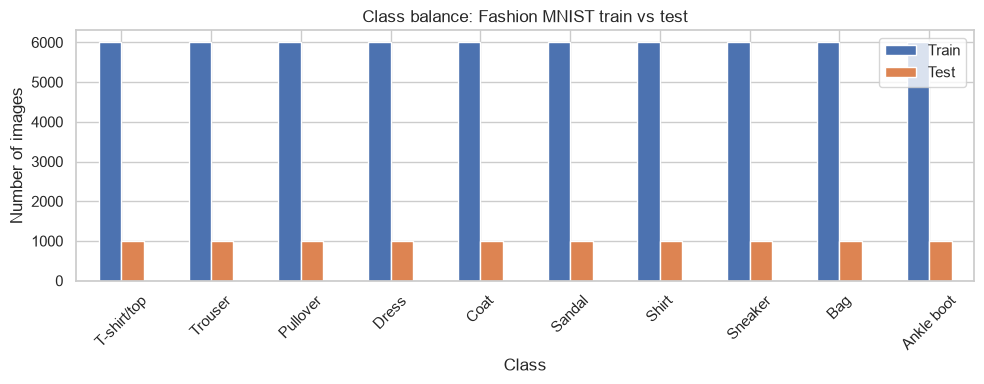

In [7]:
balance_df.plot(x='Class', y=['Train', 'Test'], kind='bar', figsize=(10, 4), rot=45)
plt.title('Class balance: Fashion MNIST train vs test')
plt.ylabel('Number of images')
plt.tight_layout()
plt.show()

### Sanity-check labels by sampling images

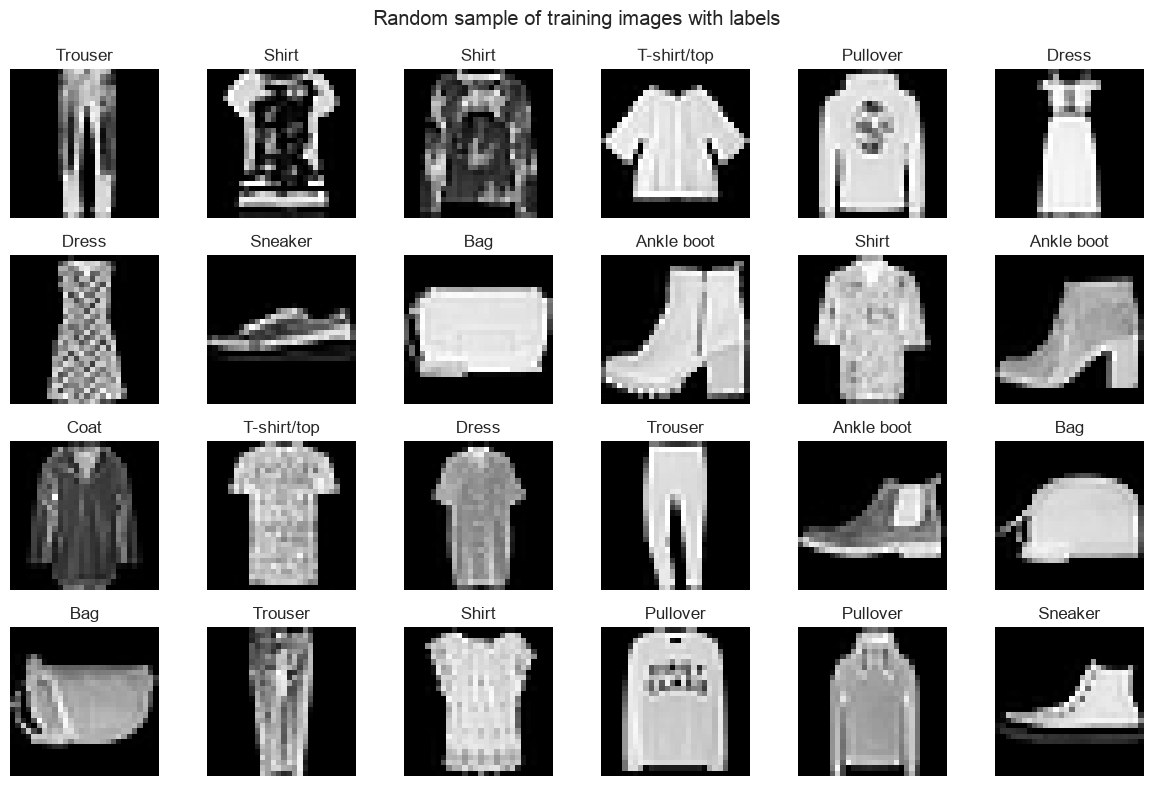

In [8]:
fig, axes = plt.subplots(4, 6, figsize=(12, 8))
for i, ax in enumerate(axes.flat):
    idx = np.random.randint(0, len(X_train))
    ax.imshow(X_train[idx, :, :, 0], cmap='gray')
    ax.set_title(class_names[y_train[idx]])
    ax.axis('off')
plt.suptitle('Random sample of training images with labels')
plt.tight_layout()
plt.show()

## 4. Train / Validation / Test Split

**Why:** Dedicated validation set used during training for early stopping (not just cross-validation — training is expensive). Test set is held out until the very end.

In [9]:
# Hold out 20% of the training set as validation, stratified to keep class balance
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.2, stratify=y_train, random_state=42
)

print('Train:', X_train.shape)
print('Val  :', X_val.shape)
print('Test :', X_test.shape)

Train: (48000, 28, 28, 1)
Val  : (12000, 28, 28, 1)
Test : (10000, 28, 28, 1)


### Data augmentation

**Why:** Augment images to increase the effective dataset size and reduce overfitting. Note: Fashion MNIST includes mirrored-looking classes (e.g. pullover vs coat), so we only use mild shifts.

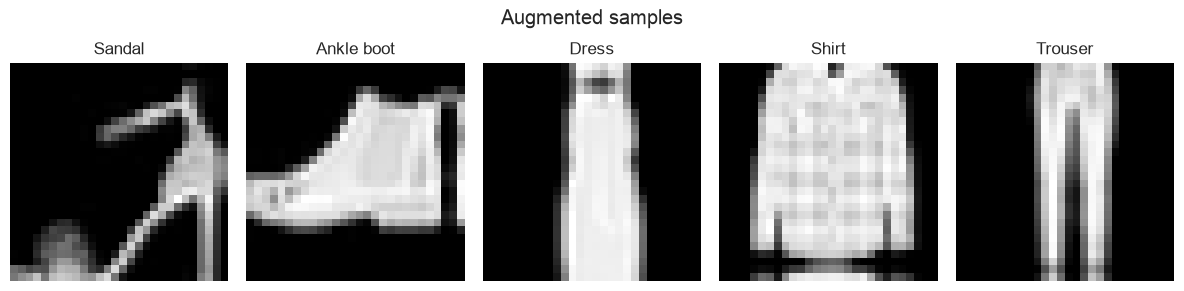

In [10]:
data_augmentation = keras.Sequential([
    layers.RandomTranslation(height_factor=0.1, width_factor=0.1),
    layers.RandomFlip('horizontal'),
], name='data_augmentation')

# Visualise augmented examples
fig, axes = plt.subplots(1, 5, figsize=(12, 3))
example = X_train[5:10]
aug = data_augmentation(example, training=True)
for i, ax in enumerate(axes.flat):
    ax.imshow(aug[i, :, :, 0].numpy(), cmap='gray')
    ax.axis('off')
    ax.set_title(class_names[y_train[5 + i]])
plt.suptitle('Augmented samples')
plt.tight_layout()
plt.show()

## 5. Model Training (CNN)

**How it works:**
- **Forward pass** computes predictions.
- **Backpropagation** computes gradients.
- An **optimiser (Adam)** updates the weights over many epochs.

We tune architecture (conv+pool layers), regularisation (dropout), batch size, and learning rate. **Early stopping** monitors the validation loss to stop training before overfitting.

In [11]:
model = keras.Sequential([
    layers.Input(shape=(28, 28, 1)),
    data_augmentation,

    layers.Conv2D(32, kernel_size=3, activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.Conv2D(32, kernel_size=3, activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(pool_size=2),
    layers.Dropout(0.25),

    layers.Conv2D(64, kernel_size=3, activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.Conv2D(64, kernel_size=3, activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(pool_size=2),
    layers.Dropout(0.25),

    layers.Flatten(),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax'),
], name='fashion_cnn')

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
)

model.summary()

Model: "fashion_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     1,606,144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,677,034 (6.40 MB)

 Trainable params: 1,676,650 (6.40 MB)

 Non-trainable params: 384 (1.50 KB)

In [12]:
callbacks = [
    keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-5),
]

EPOCHS = 30
BATCH_SIZE = 128

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks,
    verbose=1,
)

Epoch 1/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 38s 98ms/step - accuracy: 0.7365 - loss: 0.7543 - val_accuracy: 0.5820 - val_loss: 1.9202 - learning_rate: 0.0010
Epoch 2/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 37s 98ms/step - accuracy: 0.8117 - loss: 0.4984 - val_accuracy: 0.8795 - val_loss: 0.3253 - learning_rate: 0.0010
Epoch 3/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 40s 105ms/step - accuracy: 0.8365 - loss: 0.4397 - val_accuracy: 0.8839 - val_loss: 0.3144 - learning_rate: 0.0010
Epoch 4/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 45s 121ms/step - accuracy: 0.8501 - loss: 0.4039 - val_accuracy: 0.8998 - val_loss: 0.2688 - learning_rate: 0.0010
Epoch 5/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 58s 154ms/step - accuracy: 0.8598 - loss: 0.3805 - val_accuracy: 0.9026 - val_loss: 0.2697 - learning_rate: 0.0010
Epoch 6/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 59s 158ms/step - accuracy: 0.8681 - loss: 0.3616 - val_accuracy: 0.9102 - val_loss: 0.2476 - learning_rate: 0.0010
Epoch 7/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 60s 159ms/step - accuracy: 0.873

## 6. Evaluation Metrics & Loss Curves

**Metrics for classification:** Accuracy, Precision, Recall, F1, ROC-AUC. **Also track train/validation loss curves.**

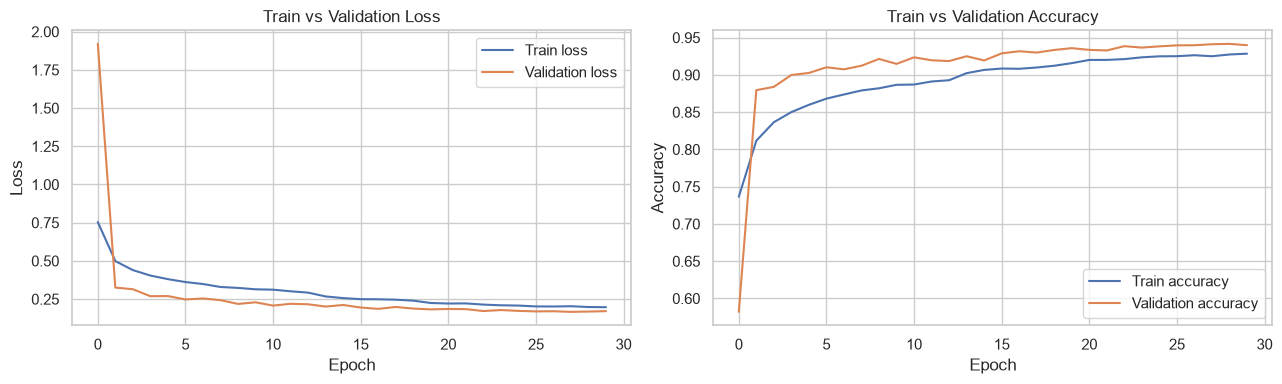

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(history.history['loss'], label='Train loss')
axes[0].plot(history.history['val_loss'], label='Validation loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Train vs Validation Loss')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history.history['accuracy'], label='Train accuracy')
axes[1].plot(history.history['val_accuracy'], label='Validation accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Train vs Validation Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

### Evaluate on the held-out test set

In [14]:
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f'Test loss: {test_loss:.4f}')
print(f'Test accuracy: {test_acc:.4f}')

Test loss: 0.1856
Test accuracy: 0.9311


In [15]:
y_pred = model.predict(X_test, verbose=0)
y_pred_class = np.argmax(y_pred, axis=1)

print('Accuracy :', accuracy_score(y_test, y_pred_class))
print('Precision:', precision_score(y_test, y_pred_class, average='weighted'))
print('Recall   :', recall_score(y_test, y_pred_class, average='weighted'))
print('F1       :', f1_score(y_test, y_pred_class, average='weighted'))
# ROC-AUC computed one-vs-rest over the 10 classes
y_test_onehot = keras.utils.to_categorical(y_test, 10)
print('ROC-AUC  :', roc_auc_score(y_test_onehot, y_pred, average='weighted', multi_class='ovr'))

Accuracy : 0.9311
Precision: 0.9317169945350191
Recall   : 0.9311
F1       : 0.9312182339534586
ROC-AUC  : 0.9966191666666667


In [16]:
print(classification_report(y_test, y_pred_class, target_names=class_names))

              precision    recall  f1-score   support

 T-shirt/top       0.90      0.86      0.88      1000
     Trouser       0.99      0.99      0.99      1000
    Pullover       0.92      0.89      0.91      1000
       Dress       0.93      0.94      0.94      1000
        Coat       0.89      0.91      0.90      1000
      Sandal       0.99      0.99      0.99      1000
       Shirt       0.77      0.80      0.79      1000
     Sneaker       0.95      0.98      0.97      1000
         Bag       0.99      0.99      0.99      1000
  Ankle boot       0.99      0.95      0.97      1000

    accuracy                           0.93     10000
   macro avg       0.93      0.93      0.93     10000
weighted avg       0.93      0.93      0.93     10000



### Confusion matrix

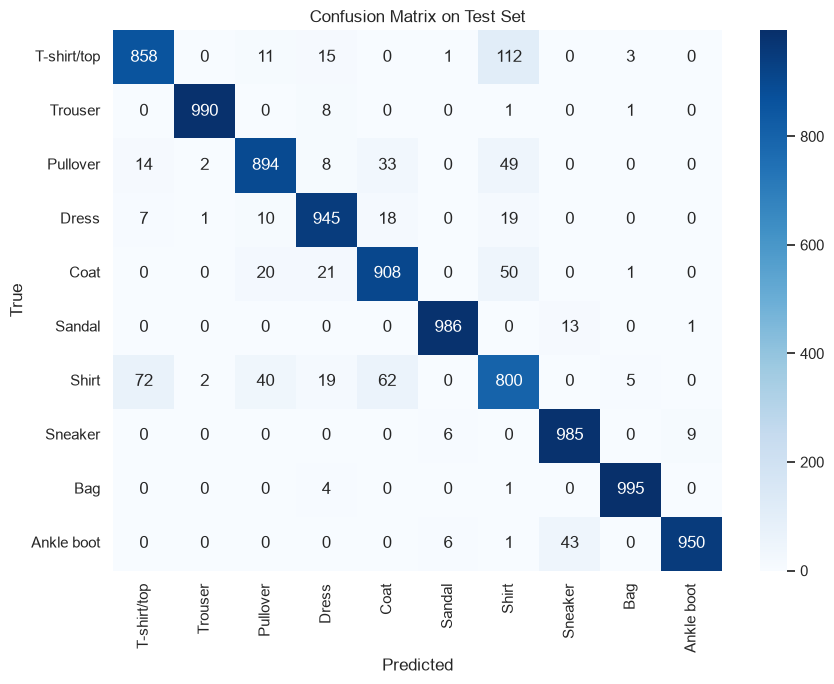

In [17]:
cm = confusion_matrix(y_test, y_pred_class)
plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix on Test Set')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.show()

## 7. Error Analysis

**Why:** Inspect misclassified examples to see whether labels, augmentation, or architecture need adjustment — and use the loss/accuracy curves to catch overfitting or underfitting.

Number of misclassified examples: 689 out of 10000


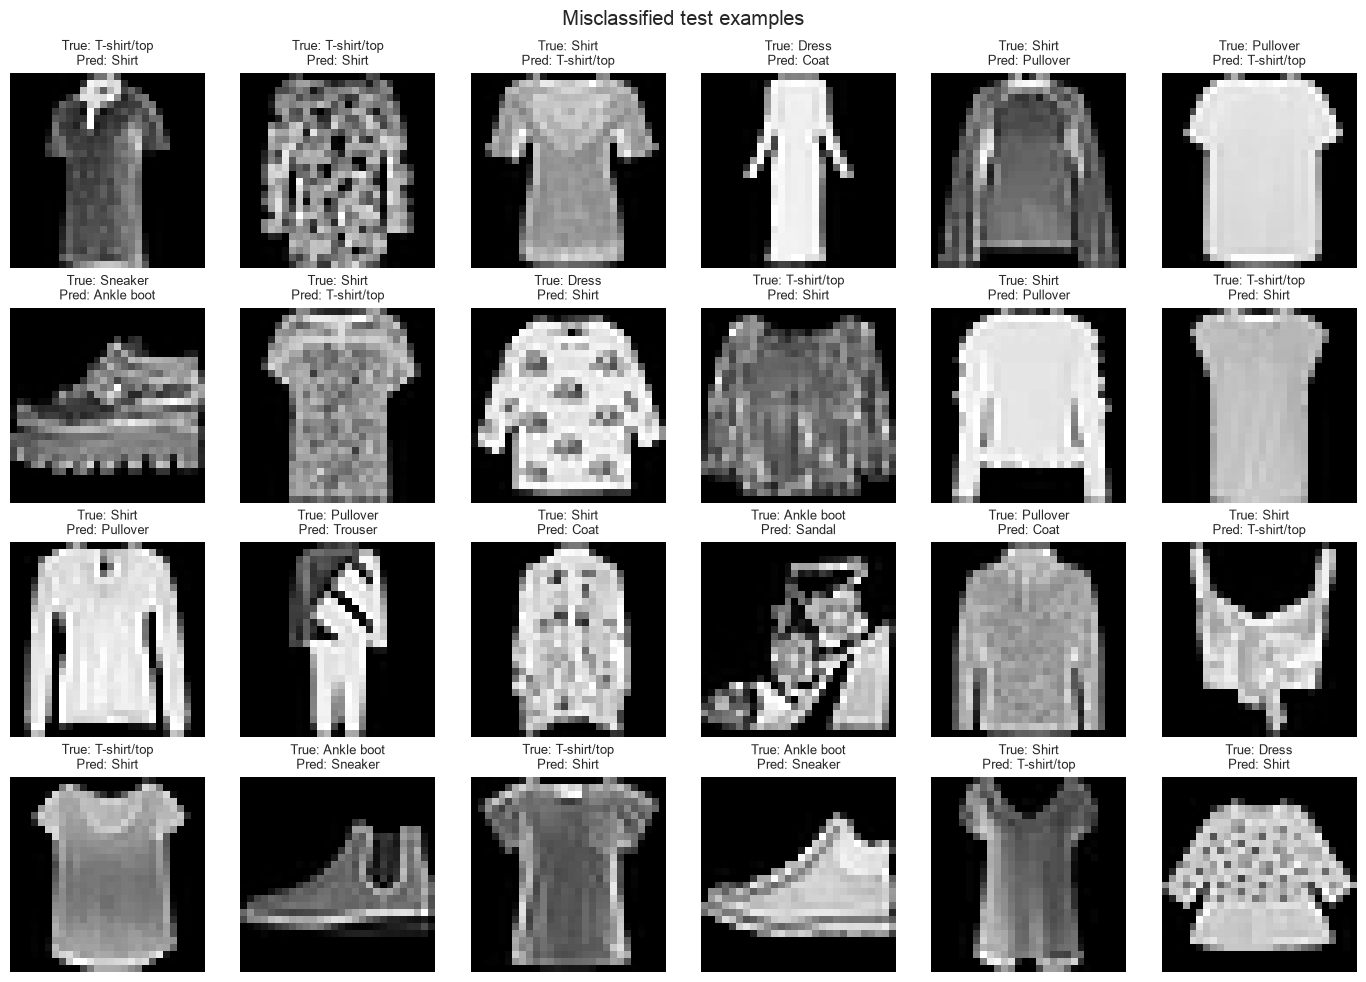

In [19]:
misclassified = np.where(y_pred_class != y_test)[0]
print(f'Number of misclassified examples: {len(misclassified)} out of {len(y_test)}')

fig, axes = plt.subplots(4, 6, figsize=(14, 10))
sample = np.random.choice(misclassified, size=24, replace=False)
for ax, idx in zip(axes.flat, sample):
    ax.imshow(X_test[idx, :, :, 0], cmap='gray')
    ax.set_title(f'True: {class_names[y_test[idx]]}\nPred: {class_names[y_pred_class[idx]]}', fontsize=9)
    ax.axis('off')
plt.suptitle('Misclassified test examples')
plt.tight_layout()
plt.show()

Most errors occur between visually similar classes (e.g. Pullover vs Coat, T-shirt vs Shirt). This suggests the confusion is inherent to near-identical garments; options to improve include more/better data, longer training, different architecture, or image scaling.

## 7b. Test the Model on Sample Images

Once trained, we can feed single images through the model. We start with a helper that predicts, displays the image, and shows the model's confidence.

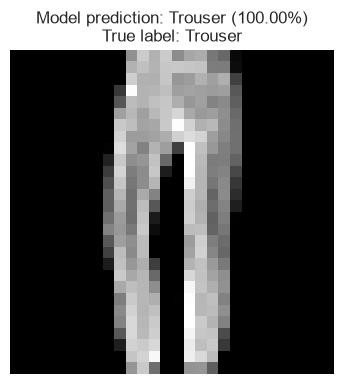

In [34]:
def predict_image(X, y_true=None, title='Model prediction'):
    pred = model.predict(X, verbose=0)
    pred_class = int(np.argmax(pred, axis=1)[0])
    confidence = float(np.max(pred))
    plt.figure(figsize=(4, 4))
    plt.imshow(X[0, :, :, 0], cmap='gray')
    label = f'{title}: {class_names[pred_class]} ({confidence:.2%})'
    if y_true is not None:
        label += f'\nTrue label: {class_names[y_true]}'
    plt.title(label)
    plt.axis('off')
    plt.tight_layout()
    plt.show()
    return pred_class, pred


# Test on a single random test image (model has never seen these examples during training)
idx = np.random.randint(0, len(X_test))
pred_class, pred = predict_image(X_test[idx:idx + 1], y_test[idx])

Top-3 classes:
  Trouser     : 100.00%
  T-shirt/top : 0.00%
  Pullover    : 0.00%


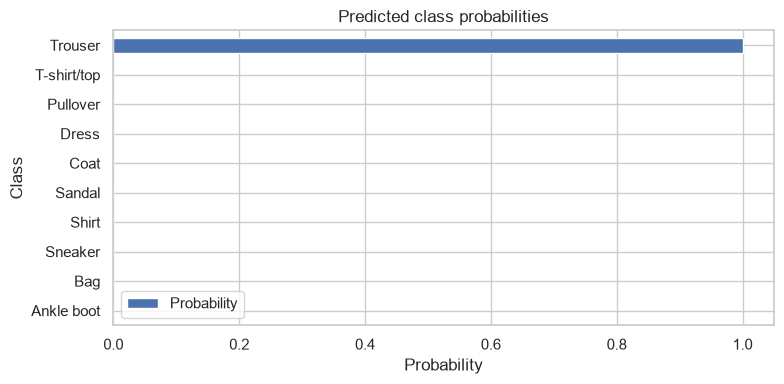

In [35]:
# Show the probability the model assigns to every class
# and the top-3 most likely classes
probabilities = pd.DataFrame({
    'Class': class_names,
    'Probability': pred[0].round(4),
}).sort_values('Probability', ascending=False)
print('Top-3 classes:')
for rank, row in probabilities.head(3).iterrows():
    print(f'  {row["Class"]:12s}: {row["Probability"]:.2%}')

probabilities.plot(x='Class', y='Probability', kind='barh', figsize=(8, 4))
plt.title('Predicted class probabilities')
plt.xlabel('Probability')
plt.tight_layout()
plt.gca().invert_yaxis()
plt.show()

### Test with your own image file

An external photo must be preprocessed to look like the training data. Fashion MNIST images have:

1. a **black background** with the garment **lighter than the background**,
2. the garment **centred and filling most of a square frame**,
3. a size of 28×28 grayscale, values in [0, 1].

A typical product photo violates all three: it has a *white* background, the item does not fill the frame, and it is not square. The function below crops to the item, pads to a square, inverts the polarity if the background is bright, and normalises.

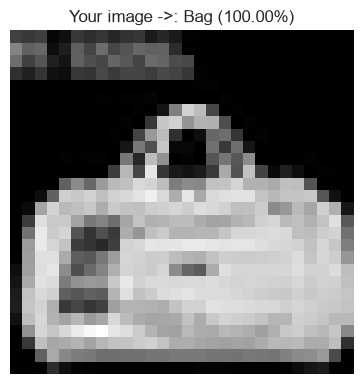

Top-3 predictions:
  Bag         : 100.00%
  Sandal      : 0.00%
  T-shirt/top : 0.00%


In [59]:
from PIL import Image

def preprocess_image(path):
    # 1. grayscale
    im = Image.open(path).convert('L')

    # 2. crop to the item (bounding box of pixels that differ from the background)
    a = np.array(im)
    bg = np.median(a)                      # background brightness (white or black)
    mask = np.abs(a.astype(int) - int(bg)) > 25
    rows = np.where(mask.any(axis=1))[0]
    cols = np.where(mask.any(axis=0))[0]
    if len(rows) and len(cols):
        im = im.crop((cols.min(), rows.min(), cols.max() + 1, rows.max() + 1))

    # 3. pad to a square so the aspect ratio is not distorted
    side = max(im.size)
    sq = Image.new('L', (side, side), int(bg))
    sq.paste(im, ((side - im.width) // 2, (side - im.height) // 2))

    # 4. resize to 28x28
    sq = sq.resize((28, 28), Image.Resampling.LANCZOS)
    arr = np.array(sq).astype('float32') / 255.0

    # 5. match Fashion MNIST polarity: dark background, light garment
    if arr[0].mean() > 0.5:                # bright background -> invert
        arr = 1.0 - arr

    return arr[np.newaxis, ..., np.newaxis]   # shape (1, 28, 28, 1)


# --- CHANGE THIS to the path of your own image ---
image_path = 'samples/duffel-bag.jpeg'
# -----------------------------------------------

X_custom = preprocess_image(image_path)
pred_class, pred = predict_image(X_custom, title='Your image ->')

top = np.argsort(pred[0])[::-1]
print('Top-3 predictions:')
for rank in top[:3]:
    print(f'  {class_names[rank]:12s}: {pred[0][rank]:.2%}')

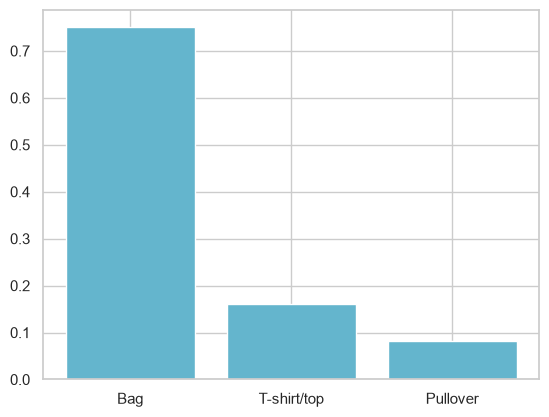

In [57]:
# show the probability of the top-3 predictions in a bar chart
top3_names = [class_names[i] for i in top[:3]]

plt.bar(top3_names, pred[0][top[:3]], color='c')
plt.show()

Note: the `data_augmentation` layers are only active during training, so prediction results are deterministic and stable.

## 8. Summary: Pros, Cons & Real-World Examples

**Pros:**
- Learns complex non-linear patterns automatically.
- State of the art on unstructured data (images, audio, text).
- Highly flexible architecture choices.

**Cons:**
- Needs large amounts of data and compute.
- Many hyperparameters to tune.
- Prone to overfitting on small data.
- Low interpretability ('black box').

**Real-world examples:**
- Image recognition (classification, object detection, segmentation)
- Speech-to-text / audio processing
- Machine translation
- Large language models

**Guidelines checklist applied in this notebook:**
- ✔ Large dataset with complex patterns — Fashion MNIST (70k images)
- ✔ Data cleaning — no missing values; normalised to [0, 1]
- ✔ EDA — class balance check + label sanity-check via image samples
- ✔ Train/validation/test split — stratified split + early stopping on validation loss
- ✔ Augmentation — mild translation/flip to grow effective dataset size
- ✔ Model training — forward pass, backprop, Adam optimiser, tuned architecture/lr/batch/dropout
- ✔ Evaluation — Accuracy, Precision, Recall, F1, ROC-AUC, train/val loss curves
- ✔ Error analysis — misclassification examples inspected